In [1]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.inspection import permutation_importance
import json
import pickle
from tqdm import tqdm

In [2]:
# Setting up the working directory and loading the dataset
WORK_DIR = Path("/Users/muhammadabdul/Desktop/penn/earth_genome_internship/climate_trace/")
df = pd.read_csv(WORK_DIR / "data/KS_barton_lot_pond/merged_data_embeddings_sp.csv")

In [3]:
# Define target and features
TARGET_COL = "facility_type"
DROP_COLS = [TARGET_COL, "geometry"]

X = df.drop(columns=[col for col in DROP_COLS if col in df.columns])
y = df[TARGET_COL]

In [4]:
# Random Forest model pipeline
model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y if y.nunique() > 1 else None,
)

In [6]:
# Fit and evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Train size: 11930 | Test size: 5114
Accuracy: 0.9947
F1-score (lot): 0.9930
F1-score (other): 0.9936
F1-score (pond): 0.9980


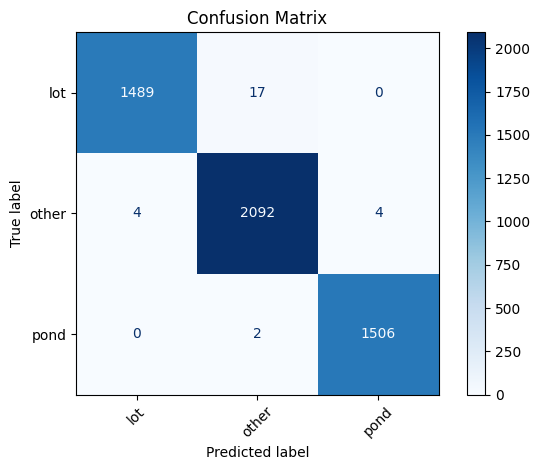

In [7]:
# Print results
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
for cls in sorted(y_test.unique()):
    print(f"F1-score ({cls}): {report[cls]['f1-score']:.4f}")

# Confusion matrix visualization
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Plotting the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [8]:
# training final model on entire dataset
final_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs = -1)
final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
# Save model and results with timestamp
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
model_dir = WORK_DIR / f"sub_facility_discrimination_KS_sp/model/{timestamp}"
model_dir.mkdir(parents=True, exist_ok=True)

# Save the model using pickle
model_path = model_dir / f"model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

# Save confusion matrix with timestamp
cm_path = model_dir / f"confusion_matrix.csv"
pd.DataFrame(cm, index=labels, columns=labels).to_csv(cm_path)

# Save evaluation summary to JSON
metrics = {
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "f1_scores_by_class": {
        label: float(report[label]["f1-score"])
        for label in labels
        if label in report
    }
}

# Save metrics to JSON file
metrics_path = model_dir / f"model_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)